In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor, XGBRFRegressor

from sklearn.metrics import r2_score, root_mean_squared_error


In [52]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

# Later usage for submitting:
test_ids = test_df['id']

In [53]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


In [54]:
train_df.describe().round(2)

,id,model_year,milage,price
count,188533.00,188533.00,188533.00,188533.00
mean,94266.00,2015.83,65705.30,43878.02
std,54424.93,5.66,49798.16,78819.52
min,0.00,1974.00,100.00,2000.00
25%,47133.00,2013.00,24115.00,17000.00
50%,94266.00,2017.00,57785.00,30825.00
75%,141399.00,2020.00,95400.00,49900.00
max,188532.00,2024.00,405000.00,2954083.00


In [55]:
train_df.select_dtypes(include='object').isna().sum()/len(train_df)

brand           0.000000
model           0.000000
fuel_type       0.026961
engine          0.000000
transmission    0.000000
ext_col         0.000000
int_col         0.000000
accident        0.013006
clean_title     0.113609
dtype: float64

In [57]:
train_df.select_dtypes('object').head(1)

,brand,model,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,MINI,Cooper S Base,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes


In [58]:
categorical_cols_to_fill = ['fuel_type', 'accident', 'clean_title']
train_df[categorical_cols_to_fill] = train_df[categorical_cols_to_fill].fillna('Unknown')

In [63]:
train_df.isna().sum()/len(train_df)

id              0.0
brand           0.0
model           0.0
model_year      0.0
milage          0.0
fuel_type       0.0
engine          0.0
transmission    0.0
ext_col         0.0
int_col         0.0
accident        0.0
clean_title     0.0
price           0.0
dtype: float64

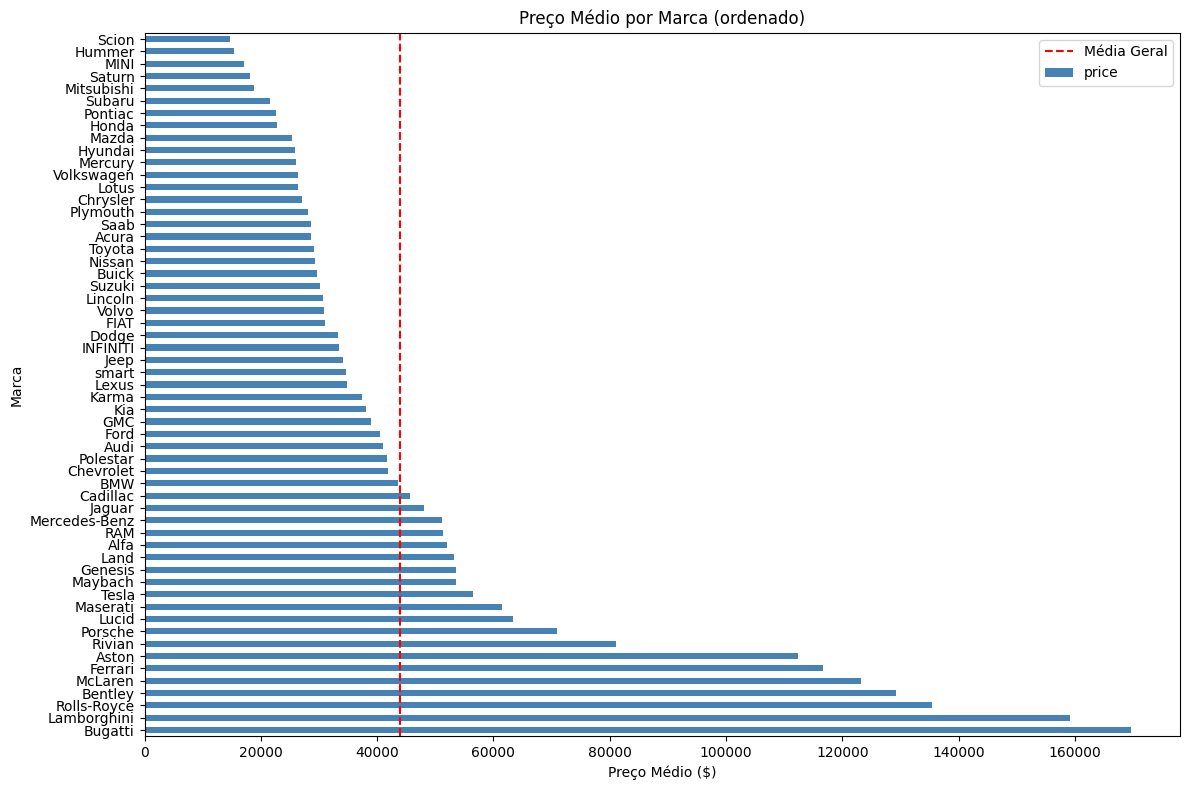

In [66]:
brand_avg_price = train_df.groupby('brand')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
brand_avg_price.plot(kind='barh', color='steelblue')
plt.xlabel('Preço Médio ($)')
plt.ylabel('Marca')
plt.title('Preço Médio por Marca (ordenado)')
plt.axvline(train_df['price'].mean(), color='red', linestyle='--', label='Média Geral')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
super_luxury_brands = ['Bugatti', 'Lamborghini', 'Rolls-Royce', 'Bentley', 'McLaren', 'Ferrari', 'Aston Martin']

train_df['is_super_luxury'] = train_df['brand'].isin(super_luxury_brands)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
Name: is_super_luxury, dtype: bool

In [69]:
luxury_premium_brands = ['Rivian', 'Porsche', 'Maserati']
train_df['is_luxury_premium'] = train_df['brand'].isin(luxury_premium_brands)

luxury_entry_brands = ['Tesla', 'Maybach', 'Genesis', 'Land Rover', 'Alfa Romeo', 'Lexus']
train_df['is_luxury_entry'] = train_df['brand'].isin(luxury_entry_brands)

premium_conventional_brands = ['Mercedes-Benz', 'Jaguar', 'Cadillac', 'BMW', 'Chevrolet']
train_df['is_premium_conventional'] = train_df['brand'].isin(premium_conventional_brands)

In [71]:
print("Super Luxury:", train_df['is_super_luxury'].sum())
print("Luxury Premium:", train_df['is_luxury_premium'].sum())
print("Luxury Entry:", train_df['is_luxury_entry'].sum())
print("Premium Conventional:", train_df['is_premium_conventional'].sum())

Super Luxury: 3134
Luxury Premium: 12141
Luxury Entry: 13353
Premium Conventional: 58528


In [72]:
train_df.head(10)

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,is_super_luxury,is_luxury_premium,is_luxury_entry,is_premium_conventional
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200,False,False,False,False
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999,False,False,False,False
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900,False,False,False,True
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000,False,False,True,False
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500,False,False,False,True
5,5,Audi,A6 2.0T Sport,2018,40950,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,White,–,None reported,Yes,29950,False,False,False,False
6,6,Audi,A8 L 3.0T,2016,62200,Gasoline,333.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Black,Black,None reported,Yes,28500,False,False,False,False
7,7,Chevrolet,Silverado 1500 1LZ,2016,102604,E85 Flex Fuel,355.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,White,Gray,None reported,Yes,12500,False,False,False,True
8,8,Ford,F-150 XLT,2020,38352,Gasoline,2.7L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,Snowflake White Pearl Metallic,Black,None reported,Yes,62890,False,False,False,False
9,9,BMW,M4 Base,2015,74850,Gasoline,425.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,Transmission w/Dual Shift Mode,Black,Blue,None reported,Yes,4000,False,False,False,True
